In [1]:
from dataloading.load_atlas import load_atlas

train_loader, val_loader, test_loader = load_atlas()

2026-01-15 20:00:54.108641: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-15 20:00:55.487222: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Found 655 image files
Found 655 mask files
Found 300 test image files
Train data: 524 files
Validation data: 131 files


monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [2]:
import matplotlib.pyplot as plt

batch = next(iter(train_loader))
image = batch['image'][0][0]

plt.imsave('atlas_slice.png', image[:, :, 100], cmap='gray')


In [3]:
from dataloading.load_brats import load_brats

brats_loader = load_brats()

Found 585 Train BRATS volumes
Found 87 Test BRATS volumes


In [4]:
batch = next(iter(brats_loader))
image = batch['image'][0][0]

plt.imsave('brats_slice.png', image[:, :, 100], cmap='gray')


ImageSeriesReader (0x55eb18743c20): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.00101728

ImageSeriesReader (0x55eb188c95d0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000545123



ImageSeriesReader (0x55eb1874cf30): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.00101728

ImageSeriesReader (0x55eb188d3380): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000545123



ATLAS statistics (after normalization):
  Min: 0.0000, Max: 0.1325
  Mean: 0.0166, Std: 0.0206

BraTS statistics (after normalization):
  Min: 0.0000, Max: 1.0000
  Mean: 0.3348, Std: 0.4000


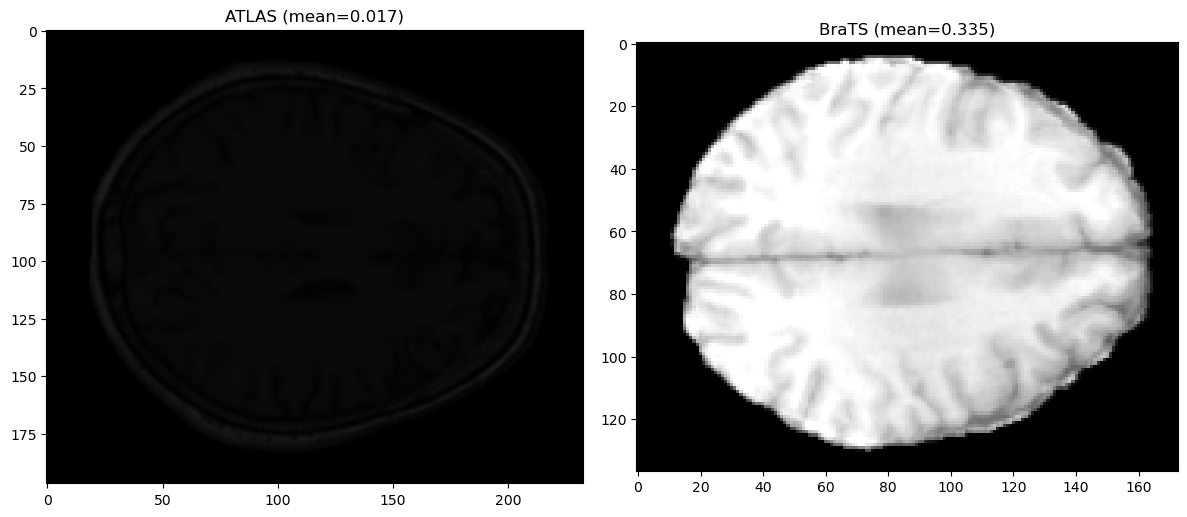

In [6]:
# Compare intensity statistics
atlas_batch = next(iter(train_loader))
atlas_image = atlas_batch['image'][0][0]

brats_batch = next(iter(brats_loader))
brats_image = brats_batch['image'][0][0]

print("ATLAS statistics (after normalization):")
print(f"  Min: {atlas_image.min():.4f}, Max: {atlas_image.max():.4f}")
print(f"  Mean: {atlas_image.mean():.4f}, Std: {atlas_image.std():.4f}")

print("\nBraTS statistics (after normalization):")
print(f"  Min: {brats_image.min():.4f}, Max: {brats_image.max():.4f}")
print(f"  Mean: {brats_image.mean():.4f}, Std: {brats_image.std():.4f}")

# Visual comparison side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(atlas_image[:, :, 100], cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'ATLAS (mean={atlas_image.mean():.3f})')
axes[1].imshow(brats_image[:, :, 100], cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'BraTS (mean={brats_image.mean():.3f})')
plt.tight_layout()
plt.show()

In [5]:
from dataloading.load_chaos import load_chaos

chaos_loader = load_chaos()

batch = next(iter(chaos_loader))
image = batch['image'][0][0]
plt.imsave('chaos_slice.png', image[:, :, 100], cmap='gray')

Found 20 Train CT volumes
Found 20 Test CT volumes
Found 0 Train MR volumes
Found 0 Test MR volumes
Total CHAOS volumes: 40
CHAOS dataloader created with 40 samples
